In [7]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [2]:
df=pd.read_csv("/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


customerID is just an identifier.These IDs do not help predict churn.

In [8]:
df.drop("customerID", axis=1, inplace=True)

Sometimes numeric columns are stored as text.

Machine learning requires numbers. converted total charges to numeric



In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

Removes rows containing missing values.

In [10]:
df.dropna(inplace=True)

Creates an encoder object

In [11]:
le = LabelEncoder()

Loops through every column.

If column contains text:

convert text → numbers

In [12]:
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

Purpose
X

Input features.

These are customer details used for prediction.

Examples:

tenure
MonthlyCharges
Contract
y

Target/output variable.

What we want to predict:

Churn

In [13]:
X = df.drop("Churn", axis=1)
y = df["Churn"]



Splits dataset into:

80% training
20% testing


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


Creates Logistic Regression model.
Increases training iterations.

Sometimes default iterations are insufficient.



In [15]:
lr_model = LogisticRegression(max_iter=1000)

Trains model using training data.

This is where learning happens.

Model studies:

customer behavior
churn patterns

In [16]:
lr_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Model predicts churn using test data.

In [17]:
y_pred = lr_model.predict(X_test)

Checks prediction correctness.

In [18]:
accuracy = accuracy_score(y_test, y_pred)

Provides deeper evaluation.

Includes:

Precision
Recall
F1-score

Especially useful for imbalance datasets.

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



Shows prediction breakdown.

In [20]:
cm = confusion_matrix(y_test, y_pred)

Visualizes confusion matrix using heatmap

<Axes: >

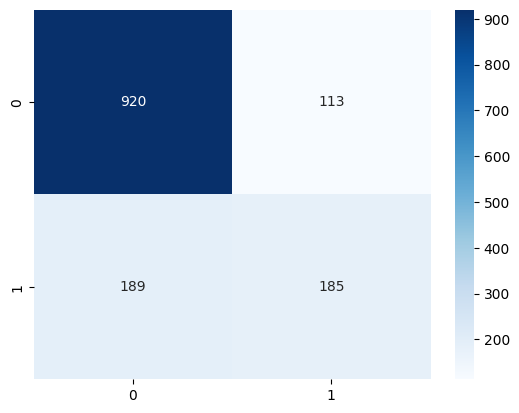

In [21]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

Creates Random Forest model.

In [22]:
rf_model = RandomForestClassifier()

Trains Random Forest model.

In [23]:
rf_model.fit(X_train, y_train)

RandomForestClassifier()

Makes predictions using Random Forest.

In [24]:
rf_pred = rf_model.predict(X_test)

Checks Random Forest accuracy

In [25]:
accuracy_score(y_test, rf_pred)

0.7867803837953091

This compares both models.

In [26]:
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nRandom Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy:
0.7853589196872779

Random Forest Accuracy:
0.7867803837953091


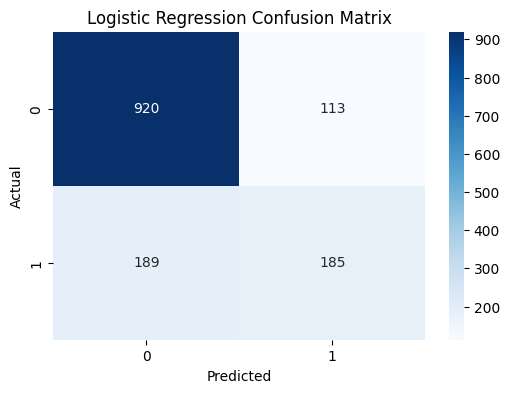

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

This part finds Which factors most affect customer churn?

In [28]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

             Feature  Importance
18      TotalCharges    0.189263
17    MonthlyCharges    0.177865
4             tenure    0.154073
14          Contract    0.086093
16     PaymentMethod    0.050729
8     OnlineSecurity    0.047347
11       TechSupport    0.038692
9       OnlineBackup    0.029103
0             gender    0.027299
7    InternetService    0.026544
15  PaperlessBilling    0.024803
2            Partner    0.023824
10  DeviceProtection    0.022246
6      MultipleLines    0.021604
1      SeniorCitizen    0.020977
3         Dependents    0.019173
12       StreamingTV    0.017650
13   StreamingMovies    0.017540
5       PhoneService    0.005172


This saves the trained model into a file.

In [29]:
import joblib

joblib.dump(rf_model, "churn_model.pkl")

['churn_model.pkl']

Loads the trained model for prediction.

In [30]:
model = joblib.load("churn_model.pkl")

example for prediction


In [31]:
new_customer = {
    'gender': 1,
    'SeniorCitizen': 0,
    'Partner': 1,
    'Dependents': 0,
    'tenure': 12,
    'PhoneService': 1,
    'MultipleLines': 0,
    'InternetService': 1,
    'OnlineSecurity': 0,
    'OnlineBackup': 1,
    'DeviceProtection': 0,
    'TechSupport': 0,
    'StreamingTV': 1,
    'StreamingMovies': 1,
    'Contract': 0,
    'PaperlessBilling': 1,
    'PaymentMethod': 2,
    'MonthlyCharges': 89.5,
    'TotalCharges': 1200
}

Convert Input to DataFrame

In [32]:
new_df = pd.DataFrame([new_customer])

Model predicts:

0 → Stay
1 → Leave

In [33]:
prediction = model.predict(new_df)

print(prediction)

[1]


In [34]:
if prediction[0] == 1:
    print("Customer is likely to churn")
else:
    print("Customer is likely to stay")

Customer is likely to churn
